tento soubor je k základní evaluaci datasetu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
df = pd.read_csv('/Users/vaclavvyhnalek/Python files/Netflix-churn/netflix_customer_churn.csv')
df.head()

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,a9b75100-82a8-427a-a208-72f24052884a,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
1,49a5dfd9-7e69-4022-a6ad-0a1b9767fb5b,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi
2,4d71f6ce-fca9-4ff7-8afa-197ac24de14b,27,Female,Standard,16.32,10,Asia,TV,13.99,0,Crypto,2,1.48,Drama
3,d3c72c38-631b-4f9e-8a0e-de103cad1a7d,53,Other,Premium,4.51,12,Oceania,TV,17.99,1,Crypto,2,0.35,Horror
4,4e265c34-103a-4dbb-9553-76c9aa47e946,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action


Základní popis datasetu:

In [3]:
print("řádky x sloupce:")
print(df.shape)

print("\nInfo:")
df.info()


řádky x sloupce:
(5000, 14)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   object 
 3   subscription_type       5000 non-null   object 
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  5000 non-null   object 
 7   device                  5000 non-null   object 
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   object 
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   object 
dtypes: fl

Rozdělení datasetu curn x non-churn

Absolutní:


churned
1    2515
0    2485
Name: count, dtype: int64

Relativní:


churned
1    0.503
0    0.497
Name: proportion, dtype: float64

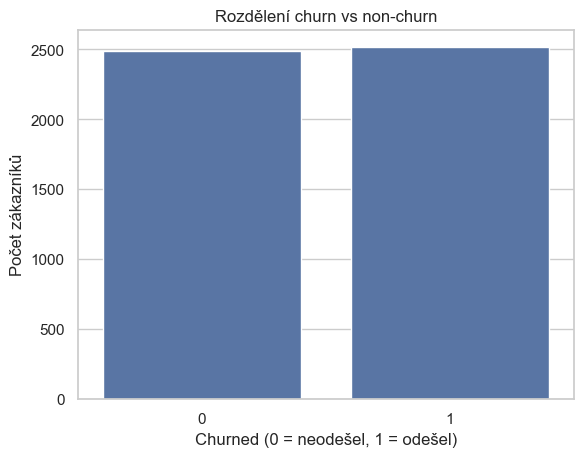

In [4]:
churn_counts = df["churned"].value_counts()
churn_ratio = df["churned"].value_counts(normalize=True)

print("Absolutní:")
display(churn_counts)
print("Relativní:")
display(churn_ratio)

sns.countplot(x="churned", data=df)
plt.title("Rozdělení churn vs non-churn")
plt.xlabel("Churned (0 = neodešel, 1 = odešel)")
plt.ylabel("Počet zákazníků")
plt.show()


Základní statistiky (mean / median / std) podle proměnné churn

In [5]:
summary = []
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_cols:
    summary.append({
        "feature": col,
        "mean_no_churn": df[df["churned"] == 0][col].mean(),
        "mean_churn": df[df["churned"] == 1][col].mean(),
        "median_no_churn": df[df["churned"] == 0][col].median(),
        "median_churn": df[df["churned"] == 1][col].median(),
        "std_no_churn": df[df["churned"] == 0][col].std(),
        "std_churn": df[df["churned"] == 1][col].std(),
    })

summary_df = pd.DataFrame(summary).round(2)
summary_df

,feature,mean_no_churn,mean_churn,median_no_churn,median_churn,std_no_churn,std_churn
0,age,43.90,43.79,44.00,44.00,15.53,15.47
1,watch_hours,17.45,5.92,13.86,4.06,13.92,5.42
2,last_login_days,21.77,38.31,19.00,41.00,16.16,14.75
3,monthly_fee,14.25,13.13,13.99,13.99,3.53,3.76
4,churned,0.00,1.00,0.00,1.00,0.00,0.00
5,number_of_profiles,3.25,2.80,3.00,3.00,1.41,1.38
6,avg_watch_time_per_day,1.59,0.16,0.72,0.12,3.57,0.19


watch_hours, last_login_days, avg_watch_time_per_day by mohli být nejdůležitější proměnné.

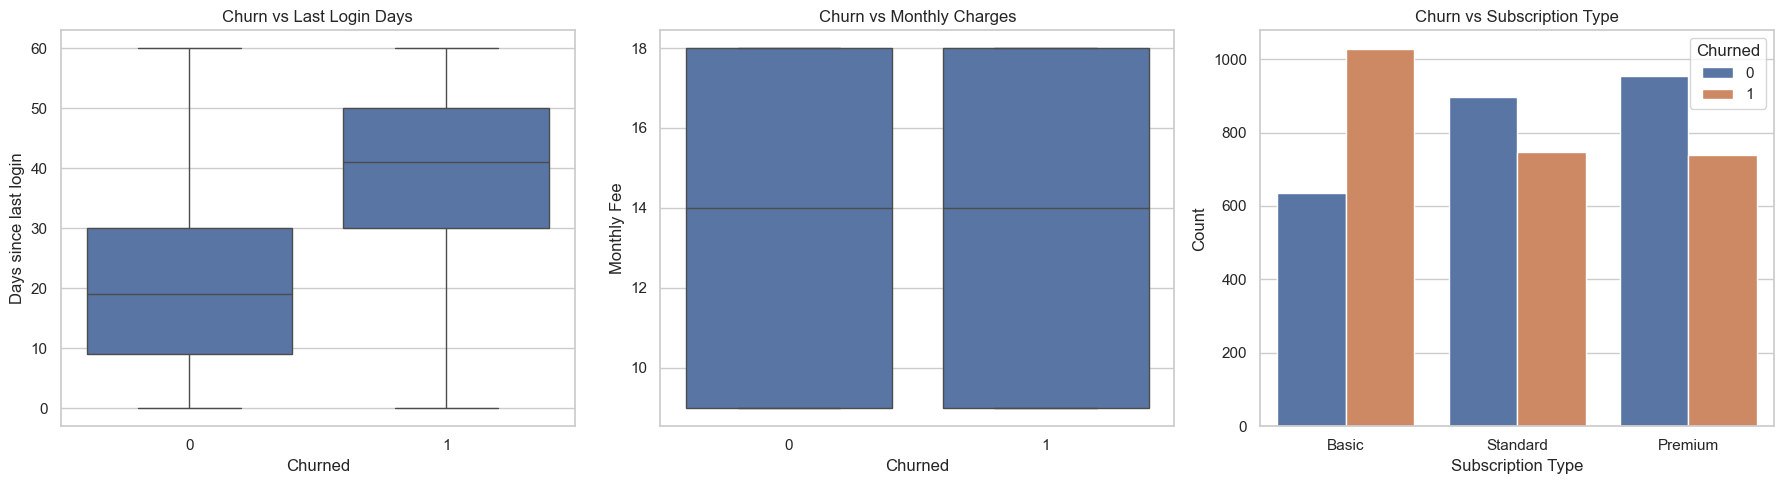

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Churn vs last_login_days
sns.boxplot(x="churned", y="last_login_days", data=df, ax=axes[0])
axes[0].set_title("Churn vs Last Login Days")
axes[0].set_xlabel("Churned")
axes[0].set_ylabel("Days since last login")

# Churn vs monthly_fee
sns.boxplot(x="churned", y="monthly_fee", data=df, ax=axes[1])
axes[1].set_title("Churn vs Monthly Charges")
axes[1].set_xlabel("Churned")
axes[1].set_ylabel("Monthly Fee")

# Churn vs subscription_type
sns.countplot(x="subscription_type", hue="churned", data=df, ax=axes[2])
axes[2].set_title("Churn vs Subscription Type")
axes[2].set_xlabel("Subscription Type")
axes[2].set_ylabel("Count")
axes[2].legend(title="Churned")

plt.tight_layout()
plt.show()

Proměnná last_login_days patří mezi klíčové faktory churnu. Jak ukazuje graf, zákazníci, kteří churnovali, měli v průměru přibližně dvojnásobnou dobu od posledního přihlášení než zákazníci, kteří zůstali. To potvrzuje, že neaktivita uživatelů je silně spojena s odchodem ze služby.
Naopak měsíční cena předplatného (monthly_fee) se jako hlavní faktor churnu nejeví. Rozdělení hodnot je u obou tříd velmi podobné a z grafu není patrný výrazný rozdíl mezi churned a non‑churned zákazníky.
Z pohledu typu předplatného je největší absolutní počet churnujících uživatelů u tarifu Basic. Zároveň je však nutné zohlednit, že součet churnujících zákazníků u tarifů Standard a Premium je výrazně vyšší než u tarifu Basic, což naznačuje, že samotný typ předplatného je potřeba hodnotit v kontextu dalších proměnných a nikoli izolovaně.

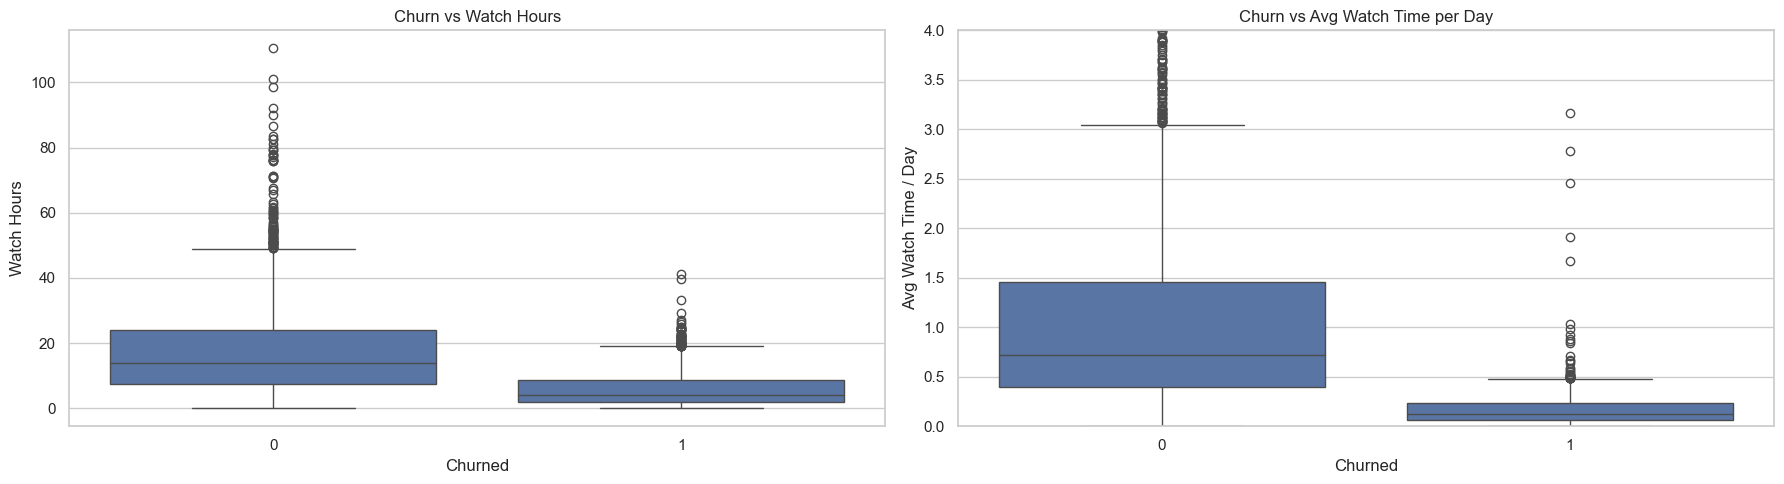

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.boxplot(x="churned", y="watch_hours", data=df, ax=axes[0])
axes[0].set_title("Churn vs Watch Hours")
axes[0].set_xlabel("Churned")
axes[0].set_ylabel("Watch Hours")

sns.boxplot(x="churned", y="avg_watch_time_per_day", data=df, ax=axes[1])
axes[1].set_title("Churn vs Avg Watch Time per Day")
axes[1].set_ylim(0,4)
axes[1].set_xlabel("Churned")
axes[1].set_ylabel("Avg Watch Time / Day")

plt.tight_layout()
plt.show()